# Week 2 — Target and size (Lantern AI)

Milestone 2 of the MKT 282 capstone. An upgrade-intent model on the September banner telemetry tells Lantern **who inside the 400,000 free users should see the $15 launch credit**, and a bridge assumption connects next week's survey to the **124,000-user qualified pool**.

**Answers for the memo**

1. **Model.** Logistic regression of `upgrade_intent_click` on pre-banner telemetry. Honest holdout AUC **0.760**. Top decile lift **2.64×**. The logit curve maps $z=X\beta$ onto $\hat{p}$; almost all users sit on the lower half of the S-curve. Excluded variable: `plans_page_views_24h_post_banner` (measured *after* the banner; it is a consequence of the click, not a predictor).
2. **Hand-verify.** User `L100002` (Exhibit 4 row): $z = -1.922$, $\hat{p} = 12.76\%$ — just below the cutoff.
3. **Cutoff.** $p^* = c/V = 3.40/24.70 = 13.8\%$. **102,320** of 400,000 clear it. Expected offer-program profit: **+$190k** targeted vs **−$388k** show-everyone.
4. **Bridge.** Conjoint respondents stand in for the 124,000 who said very/somewhat likely to pay — the *consideration* universe, not all MAU. The CBC none option does the payment discounting.
5. **Long-list + quotas.** 14 candidate attributes below, traced to telemetry and the case; occupation quotas match Exhibit 5.


## 1. Setup and dictionary

The Fact Pack is explicit: `plans_page_views_24h_post_banner` is a **post-banner** count that includes browsing after a user clicked [See plans]. Using it to predict the click is leakage. Session 2's book-offer rule also lives on this tab: show the offer if $P(\text{intent}) \ge c/V$.


In [2]:
%matplotlib inline
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import statsmodels.api as sm
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

DATA_PATH = Path("Data/Lantern_Fact_Pack.xlsx")
TARGET = "upgrade_intent_click"
LEAK = "plans_page_views_24h_post_banner"
V = 24.70
C = 3.40
P_STAR = C / V
N_MAU = 400_000
RNG = 42

NUM_FEATS = [
    "tenure_months",
    "sessions_per_week",
    "avg_msgs_per_session",
    "agent_preview_uses_30d",
    "doc_uploads_30d",
    "privacy_mode_share",
    "household_shared_device",
    "referred_by_friend",
]
CAT_FEATS = ["platform", "occupation"]


def design_matrix(frame, columns=None):
    X = frame[NUM_FEATS].copy()
    dummies = pd.get_dummies(frame[CAT_FEATS], drop_first=True, dtype=float)
    X = pd.concat([X, dummies], axis=1).astype(float)
    X = sm.add_constant(X, has_constant="add")
    if columns is not None:
        X = X.reindex(columns=columns, fill_value=0.0)
    return X


def decile_table(y, p, n_deciles=10):
    y = np.asarray(y)
    p = np.asarray(p)
    order = np.argsort(-p, kind="mergesort")
    y_s, p_s = y[order], p[order]
    n = len(y)
    base = y.mean()
    total_pos = y.sum()
    rows, cum_pos = [], 0.0
    for i, idx in enumerate(np.array_split(np.arange(n), n_deciles), 1):
        sl = slice(idx[0], idx[-1] + 1)
        k = idx[-1] - idx[0] + 1
        hits = y_s[sl].sum()
        cum_pos += hits
        rows.append(
            {
                "decile": i,
                "n": int(k),
                "mean_predicted_p": p_s[sl].mean(),
                "actual_rate": hits / k,
                "positives": int(hits),
                "lift": (hits / k) / base,
                "cum_capture": cum_pos / total_pos,
                "cum_pop": (idx[-1] + 1) / n,
            }
        )
    return pd.DataFrame(rows)


In [3]:
dictionary = pd.read_excel(DATA_PATH, sheet_name="4_Telemetry_Dictionary", header=4)
dictionary = dictionary.iloc[:, :3].dropna(how="all")
dictionary.columns = ["column", "definition", "timing"]
dictionary.dropna(subset=["column"]).reset_index(drop=True)


,column,definition,timing
0,user_id,Anonymized user key,—
1,tenure_months,Months since signup,Pre-banner
2,platform,Primary platform (iOS / Android / Web),Pre-banner
3,sessions_per_week,"Average sessions per week, trailing 60 days",Pre-banner
4,avg_msgs_per_session,"Average messages per session, trailing 60 days",Pre-banner
5,agent_preview_uses_30d,"Uses of the free life-admin agent preview, tra...",Pre-banner
6,doc_uploads_30d,"Documents uploaded, trailing 30 days",Pre-banner
7,privacy_mode_share,Share of chats started in private (no-history)...,Pre-banner
8,household_shared_device,Account shows multi-user usage patterns (0/1),Pre-banner
9,occupation,Self-reported at signup: student / professiona...,Pre-banner


**Excluded variable: `plans_page_views_24h_post_banner`.** Timing is "POST-banner window — includes browsing that happened after a user clicked." A targeting model that will score users *before* they see the launch offer cannot use a feature that does not exist until after exposure. The diagnostic below shows why an unread dictionary would produce a fake 0.99 AUC.


In [4]:
df = pd.read_excel(DATA_PATH, sheet_name="3_Free_User_Telemetry")
assert df.shape == (5000, 13)
assert df.isna().sum().sum() == 0

print(f"n = {len(df):,}   click rate = {df[TARGET].mean():.2%}   clicks = {df[TARGET].sum():.0f}")
print(f"p* = c/V = {C:.2f}/{V:.2f} = {P_STAR:.4%}  (Fact Pack rounds to 13.8%)")
print()
print("Plans-page views by click (leakage check)")
print(df.groupby(TARGET)[LEAK].describe().round(2).to_string())
print()
print(f"Click rate | views = 0 : {df.loc[df[LEAK] == 0, TARGET].mean():.1%}")
print(f"Click rate | views > 0 : {df.loc[df[LEAK] > 0, TARGET].mean():.1%}")
print(f"Share of clickers with views > 0 : {(df.loc[df[TARGET] == 1, LEAK] > 0).mean():.0%}")


n = 5,000   click rate = 9.84%   clicks = 492
p* = c/V = 3.40/24.70 = 13.7652%  (Fact Pack rounds to 13.8%)

Plans-page views by click (leakage check)
                          count   mean    std    min    25%    50%    75%    max
upgrade_intent_click                                                            
0                    4,508.0000 0.1100 0.4400 0.0000 0.0000 0.0000 0.0000 5.0000
1                      492.0000 3.2000 1.5200 1.0000 2.0000 3.0000 4.0000 9.0000

Click rate | views = 0 : 0.0%
Click rate | views > 0 : 59.8%
Share of clickers with views > 0 : 100%


## 2. Who clicked

Clickers are heavier users of life-admin and documents, more likely to be professionals and referred friends, and *less* likely to share a household device. That last pattern matters for the household-seats fence later.


In [5]:
print("Click rate by occupation")
print(df.groupby("occupation")[TARGET].agg(["mean", "count"]).assign(mean=lambda x: x["mean"].map("{:.1%}".format)))
print()
print("Click rate by platform")
print(df.groupby("platform")[TARGET].agg(["mean", "count"]).assign(mean=lambda x: x["mean"].map("{:.1%}".format)))
print()
num = NUM_FEATS + [LEAK, TARGET]
print(df.groupby(TARGET)[NUM_FEATS].mean().T.round(3).to_string())


Click rate by occupation
               mean  count
occupation                
other          5.8%   1163
professional  11.9%   2932
student        8.4%    905

Click rate by platform
           mean  count
platform              
Android    9.0%   1683
Web       10.4%   1140
iOS       10.2%   2177

upgrade_intent_click          0       1
tenure_months           15.1490 16.3110
sessions_per_week        6.6380 10.9020
avg_msgs_per_session     6.9500  9.4100
agent_preview_uses_30d   3.7850  5.7400
doc_uploads_30d          3.8890  6.5260
privacy_mode_share       0.2220  0.2590
household_shared_device  0.2320  0.1360
referred_by_friend       0.1830  0.3090


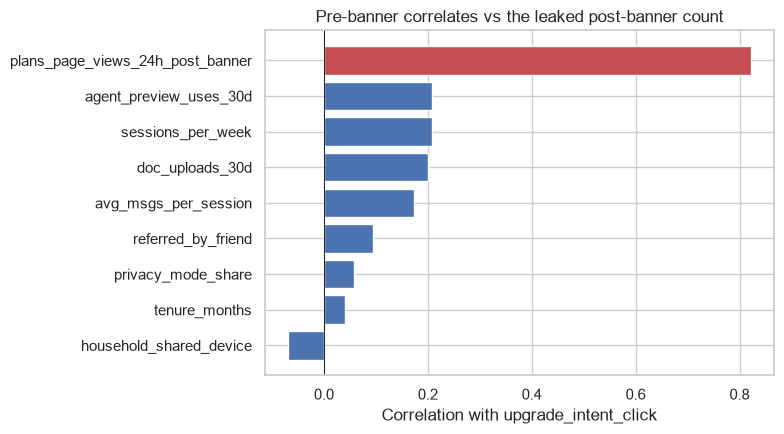

In [6]:
corr = df[NUM_FEATS + [LEAK, TARGET]].corr()[TARGET].drop(TARGET).sort_values()
fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ["#C44E52" if c == LEAK else "#4C72B0" for c in corr.index]
ax.barh(corr.index, corr.values, color=colors)
ax.axvline(0, color="black", linewidth=0.6)
ax.set_xlabel("Correlation with upgrade_intent_click")
ax.set_title("Pre-banner correlates vs the leaked post-banner count")
fig.tight_layout()


## 3. Upgrade-intent logit

Fit on a stratified 70/30 split. Score the holdout for an honest AUC. Then refit on all 5,000 for the operational scores that scale to 400,000 MAU. Reference levels: Android, occupation = other.


In [7]:
train, test = train_test_split(df, test_size=0.30, stratify=df[TARGET], random_state=RNG)
X_train = design_matrix(train)
y_train = train[TARGET].astype(float)
X_test = design_matrix(test, columns=X_train.columns)
y_test = test[TARGET].astype(float)

model_train = sm.Logit(y_train, X_train).fit(disp=False)
p_train = model_train.predict(X_train)
p_test = model_train.predict(X_test)
auc_train = roc_auc_score(y_train, p_train)
auc_test = roc_auc_score(y_test, p_test)

X_leak_train = X_train.copy()
X_leak_train[LEAK] = train[LEAK].astype(float).values
X_leak_test = X_test.copy()
X_leak_test[LEAK] = test[LEAK].astype(float).values
leak_model = sm.Logit(y_train, X_leak_train).fit(disp=False)
auc_leak = roc_auc_score(y_test, leak_model.predict(X_leak_test))

print(model_train.summary())
print()
print(f"Honest AUC  train {auc_train:.3f}   holdout {auc_test:.3f}")
print(f"Leaked AUC  holdout {auc_leak:.3f}   (do not use)")


                            Logit Regression Results                            
Dep. Variable:     upgrade_intent_click   No. Observations:                 3500
Model:                            Logit   Df Residuals:                     3487
Method:                             MLE   Df Model:                           12
Date:                  Sat, 12 Sep 2026   Pseudo R-squ.:                 0.09555
Time:                          14:18:18   Log-Likelihood:                -1017.1
converged:                         True   LL-Null:                       -1124.5
Covariance Type:              nonrobust   LLR p-value:                 2.699e-39
                              coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------
const                      -4.4002      0.267    -16.483      0.000      -4.923      -3.877
tenure_months               0.0163      0.007      2.427      0.015       0.

In [8]:
X_all = design_matrix(df)
model = sm.Logit(df[TARGET].astype(float), X_all).fit(disp=False)
p_all = model.predict(X_all)
df = df.copy()
df["p_intent"] = p_all

coef_tbl = pd.DataFrame(
    {
        "coef": model.params,
        "std_err": model.bse,
        "z": model.tvalues,
        "p_value": model.pvalues,
        "odds_ratio": np.exp(model.params),
    }
)
print("Operational model (n = 5,000). In-sample AUC "
      f"{roc_auc_score(df[TARGET], p_all):.3f}  |  mean p {p_all.mean():.2%} matches actual {df[TARGET].mean():.2%}.")
coef_tbl.style.format(
    {
        "coef": "{:.3f}",
        "std_err": "{:.3f}",
        "z": "{:.2f}",
        "p_value": "{:.4f}",
        "odds_ratio": "{:.3f}",
    }
)


Operational model (n = 5,000). In-sample AUC 0.741  |  mean p 9.84% matches actual 9.84%.


,coef,std_err,z,p_value,odds_ratio
const,-4.505,0.229,-19.71,0.0000,0.011
tenure_months,0.014,0.006,2.41,0.0161,1.014
sessions_per_week,0.058,0.011,5.08,0.0000,1.059
avg_msgs_per_session,-0.005,0.019,-0.25,0.8010,0.995
agent_preview_uses_30d,0.125,0.020,6.15,0.0000,1.134
doc_uploads_30d,0.052,0.018,2.89,0.0039,1.053
privacy_mode_share,1.612,0.268,6.01,0.0000,5.013
household_shared_device,-0.073,0.147,-0.50,0.6202,0.930
referred_by_friend,0.342,0.112,3.07,0.0022,1.408
platform_Web,0.158,0.135,1.17,0.2410,1.171


Significant positive drivers: **privacy-mode share**, **agent-preview uses**, **sessions per week**, **doc uploads**, **referred-by-friend**, **professional**, and tenure. `avg_msgs_per_session` and `household_shared_device` drop out once intensity is controlled — kept in the specification because they are theoretically motivated pre-banner features, but they do not drive scores.


## 4. Honest AUC and decile lift

Holdout n = 1,500, base rate 9.87%. A random ranking has lift 1.0 in every decile. The model is a ranking tool, not a 50% classifier — almost nobody has $\hat{p} \ge 50\%$. The logit chart below is the same fact on the probability scale: $p^*$ cuts the S-curve well below 0.5.


In [9]:
deciles = decile_table(y_test, p_test)
print(f"Holdout AUC {auc_test:.3f}   (leaked-model AUC {auc_leak:.3f} is the trap)")
print(f"Top decile lift {deciles.loc[0, 'lift']:.2f}×   |   top 30% captures {deciles.loc[2, 'cum_capture']:.1%} of clickers")
deciles.style.format(
    {
        "mean_predicted_p": "{:.1%}",
        "actual_rate": "{:.1%}",
        "lift": "{:.2f}×",
        "cum_capture": "{:.1%}",
        "cum_pop": "{:.0%}",
    }
)


Holdout AUC 0.760   (leaked-model AUC 0.990 is the trap)
Top decile lift 2.64×   |   top 30% captures 65.5% of clickers


,decile,n,mean_predicted_p,actual_rate,positives,lift,cum_capture,cum_pop
0,1,150,26.2%,26.0%,39,2.64×,26.4%,10%
1,2,150,17.4%,18.7%,28,1.89×,45.3%,20%
2,3,150,13.8%,20.0%,30,2.03×,65.5%,30%
3,4,150,11.0%,10.7%,16,1.08×,76.4%,40%
4,5,150,8.6%,9.3%,14,0.95×,85.8%,50%
5,6,150,6.5%,4.7%,7,0.47×,90.5%,60%
6,7,150,5.0%,2.0%,3,0.20×,92.6%,70%
7,8,150,4.0%,5.3%,8,0.54×,98.0%,80%
8,9,150,3.2%,1.3%,2,0.14×,99.3%,90%
9,10,150,2.3%,0.7%,1,0.07×,100.0%,100%


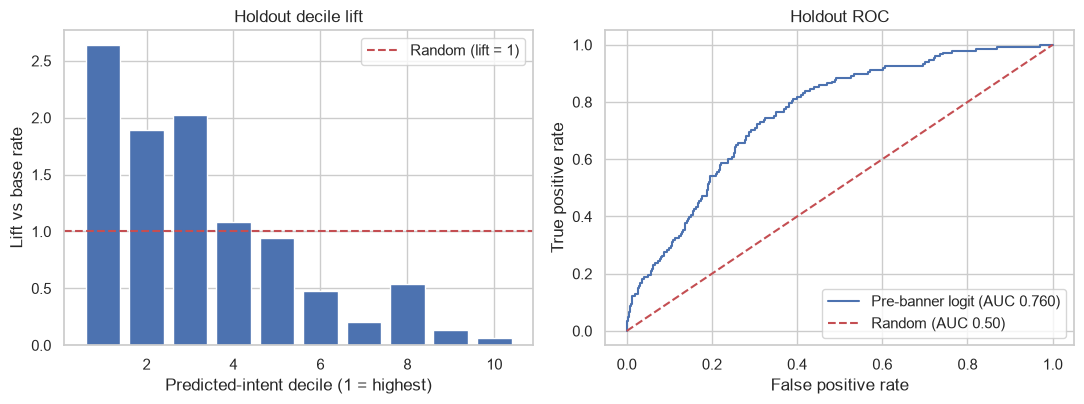

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2))

axes[0].bar(deciles["decile"], deciles["lift"], color="#4C72B0")
axes[0].axhline(1.0, color="#C44E52", linestyle="--", label="Random (lift = 1)")
axes[0].set_xlabel("Predicted-intent decile (1 = highest)")
axes[0].set_ylabel("Lift vs base rate")
axes[0].set_title("Holdout decile lift")
axes[0].legend()

fpr, tpr, _ = roc_curve(y_test, p_test)
axes[1].plot(fpr, tpr, color="#4C72B0", label=f"Pre-banner logit (AUC {auc_test:.3f})")
axes[1].plot([0, 1], [0, 1], color="#C44E52", linestyle="--", label="Random (AUC 0.50)")
axes[1].set_xlabel("False positive rate")
axes[1].set_ylabel("True positive rate")
axes[1].set_title("Holdout ROC")
axes[1].legend(loc="lower right")
fig.tight_layout()


### Logit chart

The logistic maps the linear score $z = X\beta$ onto a probability: $\hat{p} = 1/(1+e^{-z})$. The economic cutoff is a **horizontal** line at $p^* = 13.8\%$, which is a **vertical** line at $z^* = \mathrm{logit}(p^*) = -1.836$. Almost every user sits on the lower half of the S-curve — this is a ranking model, not a 50% classifier. User L100002 ($z = -1.922$, $\hat{p} = 12.76\%$) is the point just left of the cutoff in the next section.


z* = logit(p*) = -1.835   |   L100002 z = -1.922, p̂ = 12.76%   |   share with z ≥ z* = 25.58%
Intercept β = -4.505  (95% CI -4.953 to -4.057)


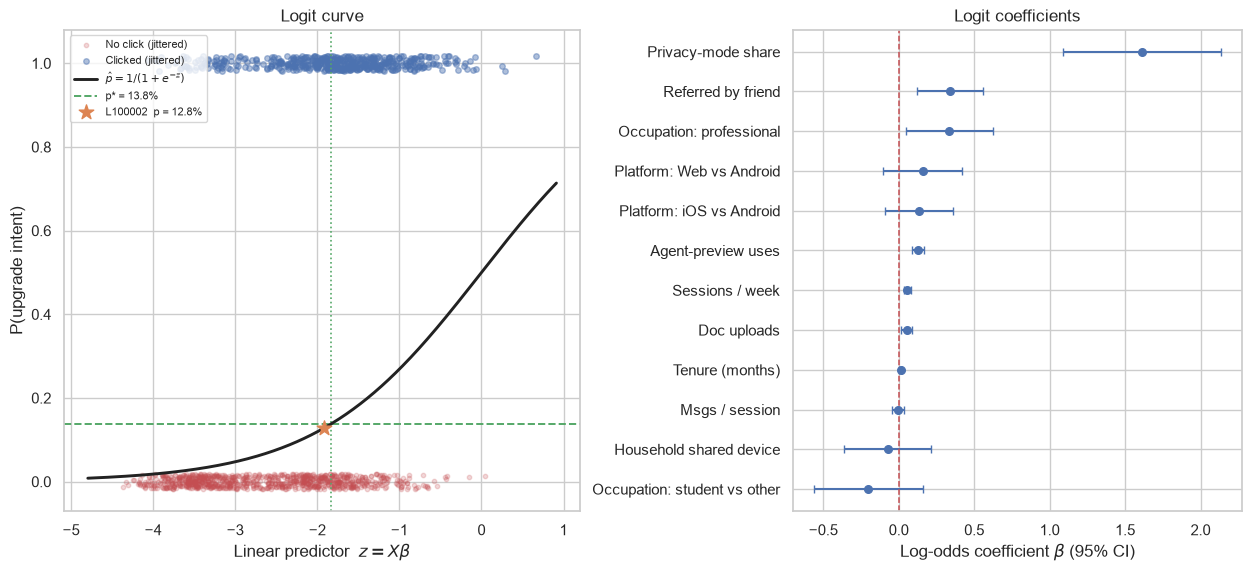

In [11]:
z_all = np.asarray(X_all @ model.params)
z_star = np.log(P_STAR / (1.0 - P_STAR))
user_row = df["user_id"].eq("L100002").to_numpy()
z_user = float(z_all[user_row][0])
p_user = float(df.loc[user_row, "p_intent"].iloc[0])

z_grid = np.linspace(z_all.min() - 0.25, max(z_all.max(), z_star) + 0.25, 400)
p_grid = 1.0 / (1.0 + np.exp(-z_grid))

clicked = df[TARGET].eq(1).to_numpy()
rng_plot = np.random.default_rng(RNG)
idx0 = np.flatnonzero(~clicked)
keep0 = rng_plot.choice(idx0, size=min(900, len(idx0)), replace=False)
idx1 = np.flatnonzero(clicked)

coef_labels = {
    "tenure_months": "Tenure (months)",
    "sessions_per_week": "Sessions / week",
    "avg_msgs_per_session": "Msgs / session",
    "agent_preview_uses_30d": "Agent-preview uses",
    "doc_uploads_30d": "Doc uploads",
    "privacy_mode_share": "Privacy-mode share",
    "household_shared_device": "Household shared device",
    "referred_by_friend": "Referred by friend",
    "platform_Web": "Platform: Web vs Android",
    "platform_iOS": "Platform: iOS vs Android",
    "occupation_professional": "Occupation: professional",
    "occupation_student": "Occupation: student vs other",
}
params = model.params.drop("const")
ci = model.conf_int().loc[params.index]
order = params.sort_values().index

fig, axes = plt.subplots(
    1, 2, figsize=(12.4, 5.6), layout="constrained",
    gridspec_kw={"width_ratios": [1.15, 1]},
)

ax = axes[0]
ax.scatter(
    z_all[keep0],
    rng_plot.uniform(-0.018, 0.018, size=len(keep0)),
    s=10,
    alpha=0.22,
    color="#C44E52",
    label="No click (jittered)",
    zorder=1,
)
ax.scatter(
    z_all[idx1],
    1.0 + rng_plot.uniform(-0.018, 0.018, size=len(idx1)),
    s=16,
    alpha=0.45,
    color="#4C72B0",
    label="Clicked (jittered)",
    zorder=2,
)
ax.plot(z_grid, p_grid, color="#222222", lw=2.1, label=r"$\hat{p}=1/(1+e^{-z})$", zorder=3)
ax.axhline(P_STAR, color="#55A868", ls="--", lw=1.4, label=f"p* = {P_STAR:.1%}")
ax.axvline(z_star, color="#55A868", ls=":", lw=1.2)
ax.scatter(
    [z_user],
    [p_user],
    s=120,
    marker="*",
    color="#DD8452",
    zorder=5,
    label=f"L100002  p = {p_user:.1%}",
)
ax.set_xlabel(r"Linear predictor  $z = X\beta$")
ax.set_ylabel("P(upgrade intent)")
ax.set_title("Logit curve")
ax.set_ylim(-0.07, 1.08)
ax.legend(loc="upper left", fontsize=8, frameon=True)

ax2 = axes[1]
y = np.arange(len(order))
ax2.errorbar(
    params.loc[order],
    y,
    xerr=np.vstack(
        [
            params.loc[order] - ci.loc[order, 0],
            ci.loc[order, 1] - params.loc[order],
        ]
    ),
    fmt="o",
    color="#4C72B0",
    ecolor="#4C72B0",
    capsize=3,
    markersize=5.5,
)
ax2.axvline(0, color="#C44E52", ls="--", lw=1.1)
ax2.set_yticks(y)
ax2.set_yticklabels([coef_labels.get(k, k) for k in order])
ax2.set_xlabel(r"Log-odds coefficient $\beta$ (95% CI)")
ax2.set_title("Logit coefficients")

print(
    f"z* = logit(p*) = {z_star:.3f}   |   "
    f"L100002 z = {z_user:.3f}, p̂ = {p_user:.2%}   |   "
    f"share with z ≥ z* = {(z_all >= z_star).mean():.2%}"
)
print(
    f"Intercept β = {model.params['const']:.3f}  "
    f"(95% CI {model.conf_int().loc['const', 0]:.3f} to {model.conf_int().loc['const', 1]:.3f})"
)



## 5. Hand-verify: user L100002

Exhibit 4's second row: 16-month Android professional, 11.8 sessions/week, 9.4 messages/session, 4 agent-preview uses, 11 doc uploads, 20% private-mode chats. Did click the banner. Predicted from the operational coefficients — the starred point on the logit curve, just left of $z^*$:


In [121]:
import random

# Pick a random user from df each time
user = df.sample(1).iloc[0]
x_user = design_matrix(df.loc[df["user_id"] == user["user_id"]], columns=X_all.columns).iloc[0]
terms = pd.DataFrame(
    {
        "feature": model.params.index,
        "beta": model.params.values,
        "x": x_user.values,
        "beta_x": model.params.values * x_user.values,
    }
)
z = terms["beta_x"].sum()
p_hat = 1 / (1 + np.exp(-z))
print(user["user_id"]) 
print(user[["user_id", "tenure_months", "platform", "sessions_per_week", "avg_msgs_per_session",
            "agent_preview_uses_30d", "doc_uploads_30d", "privacy_mode_share",
            "household_shared_device", "occupation", "referred_by_friend", TARGET]].to_string())
print()
print(terms.round(4).to_string(index=False))
print()
print(f"z = Σ βx = {z:.4f}")
print(f"P(click) = 1 / (1 + e^(−z)) = {p_hat:.4%}   model output {user['p_intent']:.4%}")
print(f"p* = {P_STAR:.2%}  →  {user['user_id']} {'CLEARS' if p_hat >= P_STAR else 'does not clear'} the launch-offer cutoff")


L102116
user_id                         L102116
tenure_months                         2
platform                        Android
sessions_per_week                8.9000
avg_msgs_per_session             7.3000
agent_preview_uses_30d                4
doc_uploads_30d                       4
privacy_mode_share               0.6500
household_shared_device               0
occupation                 professional
referred_by_friend                    0
upgrade_intent_click                  0

                feature    beta      x  beta_x
                  const -4.5049 1.0000 -4.5049
          tenure_months  0.0136 2.0000  0.0272
      sessions_per_week  0.0576 8.9000  0.5126
   avg_msgs_per_session -0.0048 7.3000 -0.0352
 agent_preview_uses_30d  0.1254 4.0000  0.5015
        doc_uploads_30d  0.0519 4.0000  0.2075
     privacy_mode_share  1.6121 0.6500  1.0478
household_shared_device -0.0726 0.0000 -0.0000
     referred_by_friend  0.3424 0.0000  0.0000
           platform_Web  0.1580 0.0000  0

Arithmetic in four decimals (Android and "other"-occupation dummies are the dropped baselines, so those $\beta x = 0$):

| Feature | $x$ | $\beta$ | $\beta x$ |
|---|---:|---:|---:|
| intercept | 1 | −4.5049 | −4.5049 |
| tenure_months | 16 | 0.0136 | 0.2180 |
| sessions_per_week | 11.8 | 0.0576 | 0.6796 |
| avg_msgs_per_session | 9.4 | −0.0048 | −0.0453 |
| agent_preview_uses_30d | 4 | 0.1254 | 0.5015 |
| doc_uploads_30d | 11 | 0.0519 | 0.5706 |
| privacy_mode_share | 0.20 | 1.6121 | 0.3224 |
| occupation_professional | 1 | 0.3360 | 0.3360 |
| **z** | | | **−1.9220** |

$$\hat{p} = \frac{1}{1+e^{1.9220}} = 12.76\%$$

L100002 is a real clicker who sits just *under* $p^*$. Targeting at 13.8% is willing to miss some true intent in order not to spend $3.40 on users whose expected contribution does not cover the credit.


## 6. $p^*$ cutoff, reach, and expected profit

Fact Pack tab 4:

$$
\text{EV}_i = P(\text{intent}_i)\times \$24.70 - \$3.40
\qquad
p^* = \frac{c}{V} = \frac{3.40}{24.70} = 13.765\% \approx 13.8\%
$$

Show user $i$ the $15 launch offer iff $\hat{p}_i \ge p^*$. Scale the 5,000-user random sample by $400{,}000 / 5{,}000 = 80$.


In [13]:
ev = df["p_intent"] * V - C
eligible = df["p_intent"] >= P_STAR
scale = N_MAU / len(df)

econ = pd.DataFrame(
    {
        "policy": ["Show everyone", "Target p ≥ 13.8%"],
        "users_shown_of_400k": [N_MAU, eligible.mean() * N_MAU],
        "share_of_MAU": [1.0, eligible.mean()],
        "mean_p_among_shown": [df["p_intent"].mean(), df.loc[eligible, "p_intent"].mean()],
        "expected_profit_400k": [ev.sum() * scale, ev[eligible].sum() * scale],
        "credit_cost_400k": [C * N_MAU, C * eligible.mean() * N_MAU],
    }
)
print(f"Sample eligible: {eligible.sum():,} / {len(df):,} = {eligible.mean():.2%}")
print(f"400k eligible:   {eligible.mean() * N_MAU:,.0f}")
print(f"Targeted minus show-everyone: ${(ev[eligible].sum() - ev.sum()) * scale:,.0f}")
print()
print(
    f"Eligible click rate (actual): {df.loc[eligible, TARGET].mean():.1%}   "
    f"vs ineligible {df.loc[~eligible, TARGET].mean():.1%}"
)
econ.style.format(
    {
        "users_shown_of_400k": "{:,.0f}",
        "share_of_MAU": "{:.1%}",
        "mean_p_among_shown": "{:.1%}",
        "expected_profit_400k": "${:,.0f}",
        "credit_cost_400k": "${:,.0f}",
    }
)


Sample eligible: 1,279 / 5,000 = 25.58%
400k eligible:   102,320
Targeted minus show-everyone: $578,011

Eligible click rate (actual): 21.1%   vs ineligible 6.0%


,policy,users_shown_of_400k,share_of_MAU,mean_p_among_shown,expected_profit_400k,credit_cost_400k
0,Show everyone,"400,000",100.0%,9.8%,"$-387,808","$1,360,000"
1,Target p ≥ 13.8%,"102,320",25.6%,21.3%,"$190,203","$347,888"


Who clears p* (share of eligible)
occupation
professional    75.7%
student         14.9%
other            9.4%

Eligible vs ineligible means
                         eligible  ineligible
tenure_months             17.2000     14.6000
sessions_per_week         13.6200      4.8000
avg_msgs_per_session      10.9200      5.9100
agent_preview_uses_30d     7.0200      2.9300
doc_uploads_30d            8.0800      2.8000
privacy_mode_share         0.2700      0.2100
household_shared_device    0.0800      0.2700
referred_by_friend         0.3900      0.1300


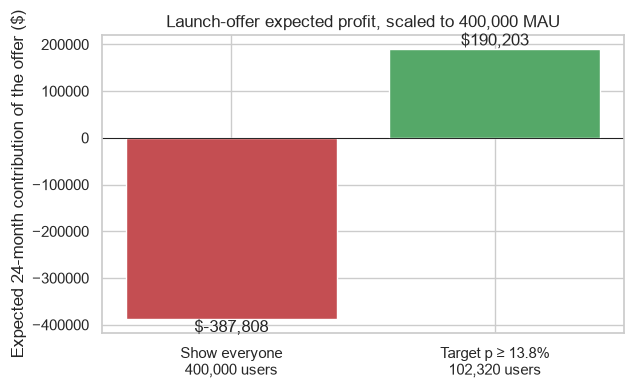

In [14]:
print("Who clears p* (share of eligible)")
print(df.loc[eligible, "occupation"].value_counts(normalize=True).map("{:.1%}".format).to_string())
print()
print("Eligible vs ineligible means")
print(
    pd.concat(
        {
            "eligible": df.loc[eligible, NUM_FEATS].mean(),
            "ineligible": df.loc[~eligible, NUM_FEATS].mean(),
        },
        axis=1,
    ).round(2)
)

fig, ax = plt.subplots(figsize=(6.5, 4))
policies = ["Show everyone\n400,000 users", "Target p ≥ 13.8%\n102,320 users"]
profits = [ev.sum() * scale, ev[eligible].sum() * scale]
colors = ["#C44E52", "#55A868"]
bars = ax.bar(policies, profits, color=colors)
ax.axhline(0, color="black", linewidth=0.6)
ax.set_ylabel("Expected 24-month contribution of the offer ($)")
ax.set_title("Launch-offer expected profit, scaled to 400,000 MAU")
for bar, val in zip(bars, profits):
    ax.text(bar.get_x() + bar.get_width() / 2, val, f"${val:,.0f}", ha="center",
            va="bottom" if val > 0 else "top")
fig.tight_layout()


**Recommendation.** Do not show the $15 credit to everyone. Mean $P(\text{intent})$ is 9.8%, below $p^*$, so blanket distribution loses about **$388k**. Scoring on pre-banner behavior and offering only the top **25.6%** (102,320 users) turns the same program into about **+$190k** expected contribution — a **$578k** swing. Lead launch messaging at **professionals who already use agent preview and upload documents** (76% of those who clear $p^*$).

Week 5 will replace planning $V = \$24.70$ with the team's own CLV.


## 7. Bridge assumption (Exhibit 5 → conjoint)

The in-app pulse (n = 12,400, weighted to MAU) defines a **qualified pool of 124,000** = 31% of 400,000 who said they are very (12%) or somewhat (19%) likely to pay in the next 12 months.

**Bridge assumption we will carry into Weeks 3–5:**

1. Our survey respondents are a sample of this **124,000-person consideration set**, not of all 400,000 MAU. People who said "unlikely" are out of scope for take-rate simulation.
2. Stated intent overstates payment. The 124,000 is the universe that *considers* paying; the conjoint **none / keep-free** option is what converts consideration into a take rate. Then $\text{take rate} \times 124{,}000 = m$ for the Bass forecast (Fact Pack dictionary).
3. We quota the sample on occupation so it matches the pulse *cut* applied to MAU mix, not the raw telemetry mix:

| Occupation | Share of MAU | Very+somewhat likely | Implied headcount | Share of 124k |
|---|---:|---:|---:|---:|
| Professional | 46% | 38% | 69,920 | 56.4% |
| Student | 22% | 30% | 26,400 | 21.3% |
| Other | 32% | 22% | 28,160 | 22.7% |

4. The **targeting list** (102,320 behavioral scores) and the **survey universe** (124,000 stated intent) are related but not the same people. Targeting decides who sees the $15 credit at launch; the qualified pool sizes the conjoint. We will not treat a conjoint take rate as if it applied to all 400,000.


In [15]:
pulse = pd.DataFrame(
    {
        "occupation": ["professional", "student", "other"],
        "share_of_MAU": [0.46, 0.22, 0.32],
        "very_or_somewhat": [0.38, 0.30, 0.22],
    }
)
pulse["headcount"] = pulse["share_of_MAU"] * pulse["very_or_somewhat"] * N_MAU
pulse["share_of_124k"] = pulse["headcount"] / pulse["headcount"].sum()
pulse["telemetry_share"] = pulse["occupation"].map(df["occupation"].value_counts(normalize=True))
pulse["eligible_share"] = pulse["occupation"].map(df.loc[eligible, "occupation"].value_counts(normalize=True))
pulse.style.format(
    {
        "share_of_MAU": "{:.0%}",
        "very_or_somewhat": "{:.0%}",
        "headcount": "{:,.0f}",
        "share_of_124k": "{:.1%}",
        "telemetry_share": "{:.1%}",
        "eligible_share": "{:.1%}",
    }
)


,occupation,share_of_MAU,very_or_somewhat,headcount,share_of_124k,telemetry_share,eligible_share
0,professional,46%,38%,"69,920",56.2%,58.6%,75.7%
1,student,22%,30%,"26,400",21.2%,18.1%,14.9%
2,other,32%,22%,"28,160",22.6%,23.3%,9.4%


## 8. Attribute long-list and recruiting plan

Twelve to fifteen conjoint candidates. Each line is traced to a telemetry pattern, a case product claim, or the competitor grid. **Swap in Week 1 interview quotes before the memo is filed** — those transcripts are not in this folder yet.

Keep price, usage, and privacy in some form (Exhibit 8). MaxDiff in Week 3 cuts this list to 5–6 attributes.


In [16]:
longlist = pd.DataFrame(
    [
        ["Usage allowance (Light / Standard / Max)", "Keep",
         "Clickers average 10.9 sessions/week vs 6.6; Exhibit 8 requires usage"],
        ["No-training guarantee", "Keep",
         "privacy_mode_share is the largest standardized coefficient (OR ≈ 5 per full private-mode shift); Lantern's identity"],
        ["Vault / on-device sensitive mode", "Keep",
         "Clickers upload 6.5 docs/30d vs 3.9; case Vault prototype; privacy fence vs ChatGPT's train-on-chats default"],
        ["Life-admin agents with click-to-approve", "Keep",
         "agent_preview_uses_30d: 5.7 vs 3.8; case 'an assistant that asks permission'"],
        ["Autopilot / recurring tasks", "Candidate",
         "Case product claim; Exhibit 2 serving cost jumps to $4.20 — a natural fence"],
        ["Email + calendar integrations", "Candidate",
         "Case life-admin (draft-and-send mail); Google/Microsoft fence on native integrations"],
        ["Full suite (docs, storage, budgeting)", "Candidate",
         "doc_uploads_30d; case forms, bills, subscriptions"],
        ["Household seats (up to 5)", "Candidate",
         "22% of MAU show shared-device patterns, but they click *less* (6.0% vs 10.9%) — test, don't assume"],
        ["Price / month ($6, $12, $20, $28, $36)", "Keep",
         "Exhibit 8 grid; Firefly failed at $19.99; $20 incumbent clone is a Week 5 mandatory benchmark"],
        ["Priority / advanced-model access", "Candidate",
         "Usage intensity of the p*-eligible group (13.6 sessions/week) vs ineligible (4.8)"],
        ["Form-filling agents (school, insurance)", "Candidate",
         "Case job-to-be-done; students are 22% of MAU and 21% of the 124k pool"],
        ["Subscription and bill tracking", "Candidate",
         "Case life-admin list; pairs with budgeting in the full-suite integration"],
        ["Trip-planning agent", "Candidate",
         "Case life-admin list; a concrete agent vs generic 'answers'"],
        ["Referral or household gift seats", "Borderline",
         "referred_by_friend OR 1.41; 39% of p*-eligible arrived via referral vs 13% of the rest"],
    ],
    columns=["attribute", "status", "trace"],
)
longlist


,attribute,status,trace
0,Usage allowance (Light / Standard / Max),Keep,Clickers average 10.9 sessions/week vs 6.6; Ex...
1,No-training guarantee,Keep,privacy_mode_share is the largest standardized...
2,Vault / on-device sensitive mode,Keep,Clickers upload 6.5 docs/30d vs 3.9; case Vaul...
3,Life-admin agents with click-to-approve,Keep,agent_preview_uses_30d: 5.7 vs 3.8; case 'an a...
4,Autopilot / recurring tasks,Candidate,Case product claim; Exhibit 2 serving cost jum...
5,Email + calendar integrations,Candidate,Case life-admin (draft-and-send mail); Google/...
6,"Full suite (docs, storage, budgeting)",Candidate,"doc_uploads_30d; case forms, bills, subscriptions"
7,Household seats (up to 5),Candidate,"22% of MAU show shared-device patterns, but th..."
8,"Price / month ($6, $12, $20, $28, $36)",Keep,Exhibit 8 grid; Firefly failed at $19.99; $20 ...
9,Priority / advanced-model access,Candidate,Usage intensity of the p*-eligible group (13.6...


### Recruiting plan (Appendix 8)

Fielding target for Weeks 3–4: **n ≥ 60 human completes** (plan for **72** to absorb QA drops). MaxDiff n ≥ 15 can be the first 15 of the same recruits. Course rules: each member recruits at least 12; at most 20% classmates.

**Quotas — occupation, matching the 124k qualified pool (not raw MAU):**

| Cell | Share of 124k | Completes at n = 72 |
|---|---:|---:|
| Professional | 56% | 40 |
| Student | 21% | 15 |
| Other | 23% | 17 |
| **Total** | 100% | **72** |
| Classmates (cap) | ≤ 20% | ≤ 14 |

Soft screens (not hard quotas): mix of iOS / Android / Web; at least some current paid-AI subscribers and some privacy-mode users, so MaxDiff is not a single persona. Exclude people who have never used a consumer AI assistant.

Screener: "In the next 12 months, how likely are you to pay for a better personal AI assistant?" — recruit very/somewhat likely only, which is the Exhibit 5 definition of the pool we claim to represent.


## Memo copy-paste

**1. Model.** Logit of banner [See plans] click on pre-banner telemetry (n = 5,000; 9.8% click). Honest holdout AUC **0.760**. Top decile lift **2.64×**; top 30% of scores capture **66%** of clickers. The logit chart maps $z=X\beta$ onto $\hat{p}=1/(1+e^{-z})$; $p^*=13.8\%$ is $z^*=-1.836$, and almost all users sit on the lower half of the S-curve. **Excluded `plans_page_views_24h_post_banner`:** it is measured in the 24 hours *after* the banner and is a near-deterministic consequence of the click (0% click rate when views = 0). Including it lifts holdout AUC to 0.99 and would be unusable at launch.

**2. Hand-verify.** For Exhibit 4 user L100002, $z = -1.922$ and $\hat{p} = 1/(1+e^{1.922}) = 12.76\%$, matching the model output. That user does not receive the $15 offer.

**3. Targeting economics.** $p^* = 3.40/24.70 = 13.8\%$. **102,320** of 400,000 MAU (25.6%) clear it. Expected profit of the offer program: **+$190k** targeted vs **−$388k** if shown to everyone. Lead with professionals who already use agent preview and upload documents.

**4. Bridge.** Survey respondents represent the 124,000 very/somewhat-likely users (occupation mix 56/21/23 professional/student/other). Stated intent overstates payment; the CBC none option discounts to a take rate; take rate × 124,000 = Bass $m$. Targeting (behavioral, 102k) and the survey universe (stated, 124k) are not the same list.

**5. Long-list / recruiting.** 14 attributes above; MaxDiff will cut to 5–6. Recruit n = 72 with occupation quotas 40 / 15 / 17, classmates ≤ 14, screener = Exhibit 5 likely-to-pay.
